## **2. Carga de datos procesados**

In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [90]:
df = pd.read_parquet("../data/processed/dataset.parquet")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# **2) Split de datos (train/test)**

### Separación de variables predictoras (X) y variable objetivo (y, "has the client subscribed a term deposit?")

In [91]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [92]:
# Separación de variables predictoras (X) y variable objetivo (y, "has the client subscribed a term deposit?")

x_features = df.drop(columns=["y", "duration", "month", "day"]) 
y_target= df["y"]

# Hacemos el split entre X y Y (80/20)
X_train, X_test, y_train, y_test =train_test_split(
    x_features, 
    y_target, test_size=0.2, 
    random_state=42,
    stratify=y_target
    )    

# Checamos el shape de las variables de entreno y prueba X, Y
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(36168, 13)
(36168,)
(9043, 13)
(9043,)


**Observación**

En `x_features`, decidimos hacer un drop de las siguientes columnas:

1. `y` es nuestra variable target - has the client subscribed a term deposit?.
2. `duration` representa la duración de la última llamada telefónica realizada al cliente. A primera vista parece una variable predictora válida, sin embargo, es una variable trampa: solo se conoce una vez que la llamada ya ocurrió, lo cual se supone no debería de conocerse. Tmabién existe una relación directa con el target, ya que a mayor duración de la llamada, mayor probabilidad de que el cliente se suscriba, lo que introduce data leakage; el objetivo es predecir antes de realizar el contacto si un cliente suscribirá un depósito a plazo, duration es excluida del entrenamiento.
3. para las variables `day_of_week`,`month`, en el EDA encontramos que estas dos variables no generan un impacto relevante en la decisión del client de suscribir un depósito a largo plazo.

## **2.1 Pipeline: preprocesamiento + modelo (evitar data leakage)**

In [93]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [95]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

### **Clasificamos cada columna como numérica o categórica**

En nuestro archivo EDA, teníamos lo siguiente:

`X_bin = X[["default","housing","loan"]]` entonces vamos a mirar que tipo de encoder es el mejor approach.

In [96]:
print(f'Variable housing:{df["housing"].value_counts()}\n')
print(f'Variable loan:{df["loan"].value_counts()}\n')
print(f'Variable default:{df["default"].value_counts()}')

Variable housing:housing
yes    25130
no     20081
Name: count, dtype: int64

Variable loan:loan
no     37967
yes     7244
Name: count, dtype: int64

Variable default:default
no     44396
yes      815
Name: count, dtype: int64


In [97]:
numeric_features = ["age", "balance", "campaign", "pdays", "previous"]
categorical_features = ["job", "marital", "education", "contact", "poutcome"]
binary_features= ["default", "housing", "loan"]

### **Pipelines y transformaciones**

In [98]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from category_encoders import TargetEncoder



# Hacemos nuestra transformación de variables binarias a numéricas (0 y 1)
for col in binary_features:
    if X_train[col].dtype == "object":  # solo si es texto, así no se hace en 0 cuando ejecutamos el código otra vez
        X_train[col] = X_train[col].map({"yes": 1, "no": 0})
        X_test[col]  = X_test[col].map({"yes": 1, "no": 0})

# Checamos la distrbución para las features binarias
for col in binary_features:
    print(X_train[col].value_counts(), "\n")

default
0    35521
1      647
Name: count, dtype: int64 

housing
1    20182
0    15986
Name: count, dtype: int64 

loan
0    30355
1     5813
Name: count, dtype: int64 



In [99]:
df['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [100]:
# Transformers

# ---------------------------Transformadores---------------------------

numeric_transformer_lr = Pipeline(
    steps=[
    ("imputer", SimpleImputer(strategy="median")), # En nuestro EDA vimos que no hay nulos en las variable numéricas, pero por si acaso imputamos con la mediana
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), # si hay un valor en tests que no estaba en train, lo reemplaza por Unknown
        ("encoder", TargetEncoder(smoothing=10)), # mezcla el promedio de categorías con el global
    ]
)
# Usamos TargetEnconder (la profe había usado Dicvectorizer) porque hay variables categóricas con muchas categorías, por ejemplo "job" y "poutcome" solo tiene 4 subcategorías

# ---------------------------Preprocesadores---------------------------

# Combinamos los transformadores usando ColumnTransformer, y dejamos las binarias tal cual (passthrough) porque ya las transformamos arriba

# ---Logistic Regression---
lr_preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer_lr, numeric_features),  
    ("cat", categorical_transformer, categorical_features),  
], remainder="passthrough")

# ---Trees que son (RandomForrest Y XGBoost)---
tree_preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),  # No hacemos escalado porque no hace falta en los trees
    ("cat", categorical_transformer, categorical_features),
], remainder="passthrough")  # binary_features pasan directo

# ---------------------------Pipelines (van dentro del mlflow---------------------------

neg_pos_ratio = (y_train == "no").sum() / (y_train == "yes").sum() # para XGBoost, no se puede escalar con class_weight, toca usar scale_pos_weight 

# scale_pos_weight = "It controls the balance of positive and negative weights" y como nuestra base esta desbalanceada, le decimos a XGBoost que le de más peso a la clase chica que es "yes" -> https://www.kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

  

## **Entrenar: levantamos el MLflow Tracking Server**

```bash
mlflow server \
  --host 127.0.0.1 \
  --port 5001 \
  --backend-store-uri sqlite:///mlflow.db \
  --default-artifact-root ./mlruns
```
Opción que me funcionó con Powershell
```powershell
mlflow server `
  --host 127.0.0.1 `
  --port 5001 `
  --backend-store-uri sqlite:///mlflow.db `
  --default-artifact-root ./mlruns
```

`Puerto: http://127.0.0.1:5001`

Y se crea el file `mlflow.db`

In [101]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5001")
print(f"tracking URI: '{mlflow.get_tracking_uri()}'")

tracking URI: 'http://127.0.0.1:5001'


In [102]:
#mlflow.search_experiments()

### **Para LogisticRegression**

1. Vamos a usar principalmente las metricas de roc_auc_score por el desbalance de nuestra variable target y el f1_score

2. Usamos como uno de los parámetros `C` -> 

- C is like your way of telling this machine how much attention to pay to these details. A high C means you're encouraging the machine to take every little detail seriously, aiming for perfection
- a low C is like advising the machine to take a step back and not to obsess over every small detail.

In [103]:
import optuna

from sklearn.metrics import (f1_score, roc_auc_score,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             )

mlflow.set_experiment("bank-marketing-lr-optuna")
mlflow.autolog()

def objective_lr(trial):
    C = trial.suggest_float("C", 1e-3, 10.0, log=True) # decimos que pruebe valores entre 0.001 y 10, y hacemos log=true para que la magnitud sea (0.001, 0.01, 0.1, 1, 10)
    max_iter = trial.suggest_categorical("max_iter", [500, 1000]) # decimos que pruebe esos valores de iteraciones especificamente.

# Creamos el Pipeline y usamos el preprocesador de regresión logística
    pipeline_lr = Pipeline(
        steps=[
            ("preprocessor", lr_preprocessor),
            ("model", LogisticRegression(
                C=C,
                max_iter=max_iter,
                class_weight="balanced",
                random_state=42
            ))
        ]
    )
# Abrimos el run de mloflow para el trial que creamos de optuna (de la función objetivo)
# en esta ocasión metí el entrenamiento y las predicciones dentro del with mlflow.start_run 
    with mlflow.start_run(run_name=f"lr_c{C}_iter{max_iter}_trial.{trial.number}", nested=True) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)
        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "logistic_regression")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag(
            "features",
            ",".join(numeric_features + categorical_features + binary_features)
        )
        mlflow.set_tag("optimization", "optuna")

        # Entrenamos el modelo
        pipeline_lr.fit(X_train, y_train)

        #las predicciones y la prob
        y_pred_lr = pipeline_lr.predict(X_test)
        y_proba = pipeline_lr.predict_proba(X_test)[:, 1]

        # Nuestras métricas, para mlflow y f1 retornado para optuna
        accuracy = accuracy_score(y_test, y_pred_lr)
        precision = precision_score(y_test, y_pred_lr, pos_label="yes")
        recall = recall_score(y_test, y_pred_lr, pos_label="yes")
        f1 = f1_score(y_test, y_pred_lr, pos_label="yes")
        auc = roc_auc_score(y_test, y_proba)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_yes_manual", f1)
        mlflow.log_metric("auc_manual", auc)

        return f1  # decidimos si mejor traer auc? 
    #f1 es buena si quieres un equilibrio entre:
    #precision: cuando predigo "yes", qué tanto acierto
    #recall: cuántos "yes" reales logro encontrar

    # auc es mejor si quiero saber la capacidad del modelo de separar clases

# ya en el studio le digo que queremos hacer esa optimización con optuna, con esa métrica que retornó la función objetivo
study_lr = optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_lr") as parent_run:  # nuestra carpeta padre del proceso
    mlflow.set_tag("stage", "hpo")
    study_lr.optimize(objective_lr, n_trials=10)

    top_trials = sorted(
    [t for t in study_lr.trials if t.value is not None],
    key=lambda t: t.value,
    reverse=True
)[:5]
    
    top_trials_data = [
    {
        "trial_number": t.number,
        "f1": t.value,
        "params": t.params
    }
    for t in top_trials
]
    # Best params
    best_params = study_lr.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1", study_lr.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials.json") # Guardar como artifacts
    mlflow.log_dict(best_params, "optuna_best_params.json") # Guardar como artifacts

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_lr.best_params}")
print(f"Best F1: {study_lr.best_value}")
print(f"Best trial: {study_lr.best_trial.number}")
print(f"Best trial MLflow run id: {study_lr.best_trial.user_attrs.get('mlflow_run_id')}")



2026/04/12 18:22:03 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/12 18:22:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/12 18:22:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-12 18:22:04,025] A new study created in memory with name: no-name-50a1a452-82b4-4b78-85bd-50260b15f125
2026/04/12 18:22:05 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic

🏃 View run lr_c0.00120161364437003_iter500_trial.0 at: http://127.0.0.1:5001/#/experiments/1/runs/cd5919652a334e16901599a8702ac0c5
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/12 18:22:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:22:18 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run lr_c0.9235379235556206_iter500_trial.1 at: http://127.0.0.1:5001/#/experiments/1/runs/cf57bebea3a740ee9f022c6aa16065cb
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/12 18:22:30 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:22:30 WARNING mlflow.utils.autologging_utils: MLflow autolog

...

🏃 View run lr_c3.5151212449973537_iter1000_trial.7 at: http://127.0.0.1:5001/#/experiments/1/runs/af76eaae5b3f4041adddf815525d35c8
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/12 18:23:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:23:34 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run lr_c0.06200762134225664_iter500_trial.8 at: http://127.0.0.1:5001/#/experiments/1/runs/53af817cf7d44867847024c92ecc6159
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/12 18:23:43 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:23:44 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run lr_c0.05957308898886396_iter500_trial.9 at: http://127.0.0.1:5001/#/experiments/1/runs/673ea13dd38d45cea792abef2a56f960
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
🏃 View run optuna_study_lr at: http://127.0.0.1:5001/#/experiments/1/runs/e3e1f5054dee40c5a86ed7e4a382c270
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1
Parent run id: e3e1f5054dee40c5a86ed7e4a382c270
Best params: {'C': 4.353440731870981, 'max_iter': 500}
Best F1: 0.3411292227734467
Best trial: 3
Best trial MLflow run id: 59c51b532414489bb582d22dc33997f0


In [104]:
# Analizar el mejor trial

print(f"Best trial: {study_lr.best_trial.number}")
print(f"Best value (f1): {study_lr.best_value:.4f}")
print("Best params:")
for key, value in study_lr.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study_lr.best_params, "class_weight": "balanced", "random_state": 42}
best_model = LogisticRegression(**best_params)

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("model", LogisticRegression(**best_params))
    ]
)

best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

f1_best = f1_score(y_test, y_pred_best, pos_label="yes")
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, pos_label="yes")
recall_best = recall_score(y_test, y_pred_best, pos_label="yes")
auc_best = roc_auc_score(y_test, y_proba_best)

print(f"\nBest model F1: {f1_best:.4f}")
print(f"Best model Accuracy: {accuracy_best:.4f}")
print(f"Best model Precision: {precision_best:.4f}")
print(f"Best model Recall: {recall_best:.4f}")
print(f"Best model AUC: {auc_best:.4f}")

Best trial: 3
Best value (f1): 0.3411
Best params:
  C: 4.353440731870981
  max_iter: 500


2026/04/12 18:23:53 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2be661fcde0d4dff8796dd592eebb33d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/12 18:23:54 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever the

🏃 View run capricious-finch-205 at: http://127.0.0.1:5001/#/experiments/1/runs/2be661fcde0d4dff8796dd592eebb33d
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/1


2026/04/12 18:24:02 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:24:03 WARNING mlflow.utils.autologging_utils: MLflow autolog


Best model F1: 0.3411
Best model Accuracy: 0.6916
Best model Precision: 0.2274
Best model Recall: 0.6824
Best model AUC: 0.7538


**Observación**

Para el primer experimento, con `parent run id = 9525cccbd173408ba60cdec9fab05c29`, podemos concluir que:

1. el mejor trial es el 5 -- 02ead421159c4530bf22df4f6f19147f
2. Best value (f1): 0.3331
3. Best params: C: 0.34616776365583773 y max_iter: 500

El modelo presenta un desempeño aceptable en términos de `accuracy`; sin embargo, dado que la variable objetivo está desbalanceada, esta métrica por sí sola puede resultar engañosa ("no" es el 88.30% y el "yes" el 11.70%). También muestra una capacidad razonable para discriminar entre las clases "Yes" y "No" con ese `AUC = 0.7297`.

Además, el modelo logra identificar una proporción considerable de los clientes que sí se suscriben (`recall = 62%`). No obstante, la `precision` es baja, lo que indica un número elevado de falsos positivos. Esto sugiere que el modelo tiende a sobreestimar la clase positiva, posiblemente influido por el uso de `class_weight="balanced"`.


**Visualizando la optimización de optuna para LR**

C:\Users\Simón\AppData\Local\Temp\ipykernel_33156\2547692028.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_lr)


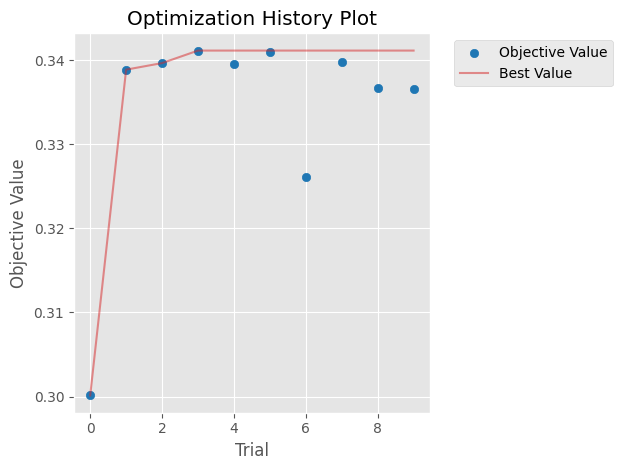

In [105]:
# Visualize optimization history
import matplotlib.pyplot as plt


# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_lr)
plt.show()

### **Funciones**:

Creamos las siguientes funcionespara trabajar más rápido y aplicar la misma lógica a modelos como Random Forest y XGBoost, y no repetir todo lo mismo que hicimos en lr.

In [106]:
def evaluate_classification_model(pipeline, X_train, y_train, X_test, y_test, pos_label=1):
    pipeline.fit(X_train, y_train)

# a la función pipeline le paso el modelo que vayamos a usar (lr, rf o xgboost)
# pasamos los datos para entrenar x_train y el y_train
# lo mismo con los de evaluar

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

# el diccionario de métricas
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label= pos_label),
        "recall": recall_score(y_test, y_pred, pos_label= pos_label),
        "f1": f1_score(y_test, y_pred, pos_label= pos_label),
        "auc": roc_auc_score(y_test, y_proba),
    }

    return y_pred, y_proba, metrics

# las métricas con el log
def log_classification_metrics(metrics):
    mlflow.log_metric("accuracy", metrics["accuracy"])
    mlflow.log_metric("precision", metrics["precision"])
    mlflow.log_metric("recall", metrics["recall"])
    mlflow.log_metric("f1_yes_manual", metrics["f1"])
    mlflow.log_metric("auc_manual", metrics["auc"])

# top_trails del study

def get_top_trials_data(study, top_n=5, metric_name="f1"):
    top_trials = sorted(
        [t for t in study.trials if t.value is not None],
        key=lambda t: t.value,
        reverse=True
    )[:top_n]

    top_trials_data = [
        {
            "trial_number": t.number,
            metric_name: t.value,
            "params": t.params,
            "mlflow_run_id": t.user_attrs.get("mlflow_run_id")
        }
        for t in top_trials
    ]

    return top_trials_data


### **Para RandomForestClassifier**


In [107]:
mlflow.set_experiment("bank-marketing-rf-optuna")
mlflow.autolog()

def objective_rf(trial):
    n_estimators = trial.suggest_categorical("n_estimators", [200, 300, 500])
    max_depth = trial.suggest_categorical("max_depth", [5, 10, 15]) 

# Creamos el Pipeline y usamos el preprocesador de regresión logística
    pipeline_rf = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]
    )
# Abrimos el run de mloflow para el trial que creamos de optuna (de la función objetivo)
# en esta ocasión metí el entrenamiento y las predicciones dentro del with mlflow.start_run 
    with mlflow.start_run(run_name=f"rf_n_estimators{n_estimators}_max_depth{max_depth}_trial.{trial.number}", nested=True) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)
        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "random_forest")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag(
            "features",
            ",".join(numeric_features + categorical_features + binary_features)
        )
        mlflow.set_tag("optimization", "optuna")

        # Entrenamos el modelo, las predicciones y la prob
        y_pred_rf, y_proba_rf, metrics = evaluate_classification_model(
            pipeline_rf, X_train, y_train, X_test, y_test, pos_label="yes"
        )

        # Nuestras métricas, para mlflow y f1 retornado para optuna
        log_classification_metrics(metrics)

        return metrics["f1"]  # accedemos a f1 

# ya en el studio le digo que queremos hacer esa optimización con optuna, con esa métrica que retornó la función objetivo
study_rf= optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_rf") as parent_run:  # nuestra carpeta padre del proceso
    mlflow.set_tag("stage", "hpo")
    study_rf.optimize(objective_rf, n_trials=10)

    top_trials_data = get_top_trials_data(study_rf, top_n=5, metric_name="f1")

    # Best params
    best_params = study_rf.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1", study_rf.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials.json") # Guardar como artifacts
    mlflow.log_dict(best_params, "optuna_best_params.json") # Guardar como artifacts

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_rf.best_params}")
print(f"Best F1: {study_rf.best_value}")
print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best trial MLflow run id: {study_rf.best_trial.user_attrs.get('mlflow_run_id')}")



2026/04/12 18:24:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/12 18:24:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/12 18:24:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-12 18:24:04,366] A new study created in memory with name: no-name-b3237610-e27e-46e2-a166-7ac72fe6af6a
2026/04/12 18:24:05 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic

🏃 View run rf_n_estimators200_max_depth15_trial.0 at: http://127.0.0.1:5001/#/experiments/2/runs/22216069cd2c4d94a31b7ffa64e73d69
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/12 18:24:19 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:24:21 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run rf_n_estimators300_max_depth10_trial.1 at: http://127.0.0.1:5001/#/experiments/2/runs/87bc7fcbe3aa4f12a9b61ca3509d1788
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/12 18:24:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:24:35 WARNING mlflow.utils.autologging_utils: MLflow autolog

...

🏃 View run rf_n_estimators200_max_depth5_trial.7 at: http://127.0.0.1:5001/#/experiments/2/runs/d48240a4d8c544ecbe5ad51b470716ca
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/12 18:26:03 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:26:05 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run rf_n_estimators200_max_depth10_trial.8 at: http://127.0.0.1:5001/#/experiments/2/runs/3b4a035da3d94b4b9d751d0e4b69ab5e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/12 18:26:15 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:26:17 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run rf_n_estimators200_max_depth5_trial.9 at: http://127.0.0.1:5001/#/experiments/2/runs/fcb73c25c6594bef91ccbc63a7e06a64
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
🏃 View run optuna_study_rf at: http://127.0.0.1:5001/#/experiments/2/runs/e1a686082041491bbff4b15ee9b91158
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2
Parent run id: e1a686082041491bbff4b15ee9b91158
Best params: {'n_estimators': 500, 'max_depth': 10}
Best F1: 0.3912073908888181
Best trial: 5
Best trial MLflow run id: 5d6f8999b6374022bbbd57b8e4d9e296


In [108]:
# Analizar el mejor trial

print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best value (f1): {study_rf.best_value:.4f}")
print("Best params:")
for key, value in study_rf.best_params.items():
    print(f"  {key}: {value}")

# Train the best model (retrain)
best_params = {**study_rf.best_params, "class_weight": "balanced", "random_state": 42}
best_model = RandomForestClassifier(**best_params)

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("model", RandomForestClassifier(**best_params))
    ]
)

best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

f1_best = f1_score(y_test, y_pred_best, pos_label="yes")
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, pos_label="yes")
recall_best = recall_score(y_test, y_pred_best, pos_label="yes")
auc_best = roc_auc_score(y_test, y_proba_best)

print(f"\nBest model F1: {f1_best:.4f}")
print(f"Best model Accuracy: {accuracy_best:.4f}")
print(f"Best model Precision: {precision_best:.4f}")
print(f"Best model Recall: {recall_best:.4f}")
print(f"Best model AUC: {auc_best:.4f}")

Best trial: 5
Best value (f1): 0.3912
Best params:
  n_estimators: 500
  max_depth: 10


2026/04/12 18:26:26 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '1119625fe39440d68fb97bd6db143aa1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/12 18:26:27 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever the

🏃 View run skillful-cod-376 at: http://127.0.0.1:5001/#/experiments/2/runs/1119625fe39440d68fb97bd6db143aa1
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/2


2026/04/12 18:26:54 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:26:55 WARNING mlflow.utils.autologging_utils: MLflow autolog


Best model F1: 0.3911
Best model Accuracy: 0.7886
Best model Precision: 0.2949
Best model Recall: 0.5803
Best model AUC: 0.7654


**Observación**

Para el primer experimento, con `parent run id = 81dc9dda53de42fdaa77a7c22d01a216`, podemos concluir que:

1. el mejor trial es el 7 -- 89f92ab86aad43cb9f48687d15e13698
2. Best value (f1): 0.3849
3. Best params: n_estimators: 500 y max_depth: 15

El modelo presenta un desempeño aceptable en términos de `accuracy`; sin embargo, dado que la variable objetivo está desbalanceada, esta métrica por sí sola puede resultar engañosa ("no" es el 88.30% y el "yes" el 11.70%). También muestra una capacidad razonable para discriminar entre las clases "Yes" y "No" con ese `AUC = 0.7215`.

Además, el modelo logra identificar una proporción moderada de los clientes que sí se suscriben (`recall = 40%`). No obstante, la `precision` mejora frente al modelo anterior, lo que indica una menor proporción de falsos positivos.



**Visualizando la optimización de optuna para LR**

C:\Users\Simón\AppData\Local\Temp\ipykernel_33156\937943704.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study_rf)


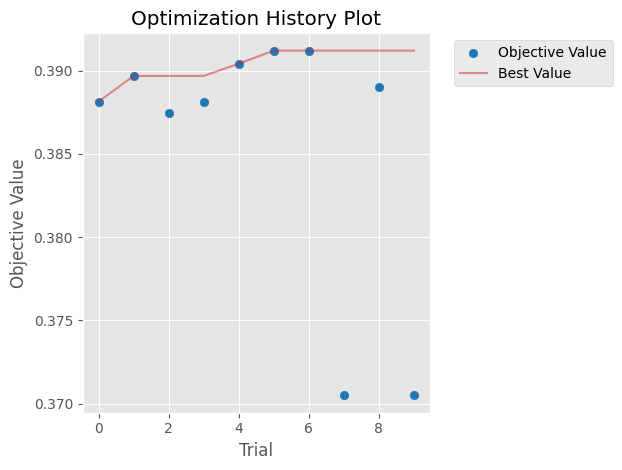

In [109]:
# Visualize optimization history
import matplotlib.pyplot as plt


# Optimization history
optuna.visualization.matplotlib.plot_optimization_history(study_rf)
plt.show()

### **Para XGBClassifier**

In [110]:
# Target codificado para XGBoost
y_train_xgb = y_train.map({"no": 0, "yes": 1})
y_test_xgb = y_test.map({"no": 0, "yes": 1})

mlflow.set_experiment("bank-marketing-xgb-optuna")
mlflow.autolog()

def objective_xgb(trial):
    n_estimators = trial.suggest_categorical("n_estimators", [200, 300, 500])
    learning_rate = trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1])
    max_depth = trial.suggest_categorical("max_depth", [3, 5, 7])
    subsample = trial.suggest_categorical("subsample", [0.8, 1.0])

    pipeline_xgb = Pipeline(
        steps=[
            ("preprocessor", tree_preprocessor),
            ("model", XGBClassifier(
                n_estimators=n_estimators,
                learning_rate=learning_rate,
                max_depth=max_depth,
                subsample=subsample,
                eval_metric="auc",
                scale_pos_weight=round(neg_pos_ratio, 2),
                random_state=42
            ))
        ]
    )

    with mlflow.start_run(
        run_name=f"xgb_n{n_estimators}_lr{learning_rate}_depth{max_depth}_trial.{trial.number}",
        nested=True
    ) as run:
        trial.set_user_attr("mlflow_run_id", run.info.run_id)

        mlflow.set_tag("problem_type", "classification")
        mlflow.set_tag("model_family", "xgboost")
        mlflow.set_tag("dataset", "bank_marketing")
        mlflow.set_tag(
            "features",
            ",".join(numeric_features + categorical_features + binary_features)
        )
        mlflow.set_tag("optimization", "optuna")

        _, _,  metrics = evaluate_classification_model(
            pipeline_xgb, X_train, y_train_xgb, X_test, y_test_xgb, pos_label=1
        )

        log_classification_metrics(metrics)

        return metrics["f1"]
    
study_xgb = optuna.create_study(direction="maximize")

with mlflow.start_run(run_name="optuna_study_xgb") as parent_run:
    mlflow.set_tag("stage", "hpo")
    study_xgb.optimize(objective_xgb, n_trials=10)

    top_trials_data = get_top_trials_data(study_xgb, top_n=5, metric_name="f1")

    best_params = study_xgb.best_params

    mlflow.log_params(best_params)
    mlflow.log_metric("best_f1", study_xgb.best_value)
    mlflow.log_dict(top_trials_data, "optuna_top_trials_xgb.json")
    mlflow.log_dict(best_params, "optuna_best_params_xgb.json")

print(f"Parent run id: {parent_run.info.run_id}")
print(f"Best params: {study_xgb.best_params}")
print(f"Best F1: {study_xgb.best_value}")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best trial MLflow run id: {study_xgb.best_trial.user_attrs.get('mlflow_run_id')}")
       


2026/04/12 18:26:56 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/04/12 18:26:56 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2026/04/12 18:26:56 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
[I 2026-04-12 18:26:56,383] A new study created in memory with name: no-name-16e9a911-ae20-416b-bb05-a7dc5c6dbbc6
2026/04/12 18:26:57 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic

🏃 View run xgb_n500_lr0.05_depth5_trial.0 at: http://127.0.0.1:5001/#/experiments/3/runs/a7920a1cb59b4a19ad9c1d4fcb6bce86
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/12 18:27:09 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:27:11 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run xgb_n500_lr0.05_depth5_trial.1 at: http://127.0.0.1:5001/#/experiments/3/runs/8d5793a8b86244dd888959a474995caf
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/12 18:27:21 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:27:22 WARNING mlflow.utils.autologging_utils: MLflow autolog

...

🏃 View run xgb_n300_lr0.01_depth5_trial.7 at: http://127.0.0.1:5001/#/experiments/3/runs/8f0473812c3b4d47ad7d28f407fbd075
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/12 18:28:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:28:26 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run xgb_n300_lr0.01_depth7_trial.8 at: http://127.0.0.1:5001/#/experiments/3/runs/589e339f2455407d87e1ba25fa6ef414
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/12 18:28:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:28:39 WARNING mlflow.utils.autologging_utils: MLflow autolog

🏃 View run xgb_n300_lr0.05_depth5_trial.9 at: http://127.0.0.1:5001/#/experiments/3/runs/378cdf60addf4015b201971aaf0c6d48
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
🏃 View run optuna_study_xgb at: http://127.0.0.1:5001/#/experiments/3/runs/eadf3ce87eba404d85cdeadeb4cd8438
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3
Parent run id: eadf3ce87eba404d85cdeadeb4cd8438
Best params: {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 7, 'subsample': 0.8}
Best F1: 0.3854135784168396
Best trial: 8
Best trial MLflow run id: 589e339f2455407d87e1ba25fa6ef414


In [111]:
best_params = {
    **study_xgb.best_params,
    "eval_metric": "auc",
    "scale_pos_weight": round(neg_pos_ratio, 2),
    "random_state": 42
}

best_pipeline_xgb = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", XGBClassifier(**best_params))
    ]
)

y_pred_best_xgb, y_proba_best_xgb, metrics_best_xgb = evaluate_classification_model(
    best_pipeline_xgb, X_train, y_train_xgb, X_test, y_test_xgb, pos_label=1
)

print(f"Best model F1: {metrics_best_xgb['f1']:.4f}")
print(f"Best model Accuracy: {metrics_best_xgb['accuracy']:.4f}")
print(f"Best model Precision: {metrics_best_xgb['precision']:.4f}")
print(f"Best model Recall: {metrics_best_xgb['recall']:.4f}")
print(f"Best model AUC: {metrics_best_xgb['auc']:.4f}")


2026/04/12 18:28:48 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '6501fbe0eb7e4bffb8a2872b25444322', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/12 18:28:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever the

🏃 View run clean-flea-238 at: http://127.0.0.1:5001/#/experiments/3/runs/6501fbe0eb7e4bffb8a2872b25444322
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/3


2026/04/12 18:29:00 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "d:\Documentos\Proyectos de Python\APRENDIZAJE AUTOMÁTICO EN LA NUBE\Trabajo final\Proyecto_final_MLops\.venv\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/12 18:29:01 WARNING mlflow.utils.autologging_utils: MLflow autolog

Best model F1: 0.3854
Best model Accuracy: 0.7708
Best model Precision: 0.2808
Best model Recall: 0.6144
Best model AUC: 0.7662


**Observación**

Para el experimento con `XGBoost`, con `parent run id = cb0281a1ea03451a84ce3cfa2c4c0476`, podemos concluir que:

1. el mejor trial es el 2 -- 2522dcc54b8b4a9eb93d7f247f93393c
2. Best value (f1): 0.400
3. Best params: n_estimators: 300, learning_rate: 0.01, max_depth: 5 y subsample: 1.0

El modelo presenta un desempeño aceptable en términos de `accuracy`; sin embargo, dado que la variable objetivo está desbalanceada, esta métrica por sí sola puede resultar engañosa ("no" es el 88.30% y el "yes" el 11.70%). También muestra una capacidad razonable para discriminar entre las clases "Yes" y "No" con ese `AUC = 0.7473`.

Además, el modelo logra identificar una proporción considerable de los clientes que sí se suscriben (`recall = 56%`). No obstante, la `precision` sigue siendo baja, lo que indica una proporción importante de falsos positivos. Esto sugiere que el modelo mantiene una capacidad relativamente buena para detectar la clase positiva, posiblemente favorecido por el uso de `scale_pos_weight` para manejar el desbalance de clases.
